# Exploration of Sofar Data and Comparison to GFSwave forecast

In [1]:
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path
import glob
from datetime import datetime, timezone

import netCDF4 as nc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import cfgrib
from scipy import interpolate

%matplotlib widget

In [2]:
# Load the sofar data example file
nc_file = '../data/nc_data/sofar_b001_xx121_20260101.nc'
sofar_data = xr.open_dataset(nc_file, engine="netcdf4")
sofar_data_day2 = xr.open_dataset('../data/nc_data/sofar_b001_xx121_20260102.nc', engine='netcdf4')

sofar_data = xr.concat([sofar_data, sofar_data_day2], dim="time")

# Basic Data cleaning
sofar_data = sofar_data.where((sofar_data['hs'] < 500) &
                              (sofar_data['wspd'] < 500) & 
                              (sofar_data['wdir'] < 500) & 
                              (sofar_data['wdir'] < 500) &
                              (sofar_data['wdir'] < 500) 
                              , drop=True)

sofar_data

<xarray.Dataset> Size: 752kB
Dimensions:    (time: 11062)
Coordinates:
  * time       (time) datetime64[ns] 88kB 2026-01-01T01:01:00 ... 2026-01-02T...
Data variables:
    lat        (time) float32 44kB -41.47 -24.37 -58.32 ... 42.79 29.5 44.25
    lon        (time) float32 44kB 116.3 -12.77 -83.27 ... -22.3 -70.61 174.2
    lstn       (time) object 88kB 'SPOT-010382' 'SPOT-010415' ... 'SPOT-32704C'
    buoy_type  (time) float64 88kB 9.0 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0 9.0
    hs         (time) float32 44kB 4.05 1.41 5.79 1.77 ... 2.17 5.66 1.6 4.21
    dsdw       (time) float64 88kB 12.0 26.0 17.0 29.0 ... 36.0 17.0 39.0 32.0
    ddwc       (time) float64 88kB 229.0 328.0 247.0 297.0 ... 55.0 306.0 211.0
    avwp       (time) float32 44kB 12.1 8.0 9.5 8.6 7.8 ... 7.5 7.7 9.1 5.7 8.8
    spwp       (time) float32 44kB 14.6 14.6 12.8 11.4 ... 10.2 12.8 8.5 10.2
    wspd       (time) float32 44kB 3.2 1.6 10.0 4.0 4.0 ... 4.8 14.4 6.0 11.2
    wdir       (time) float32 44kB 262.0 308.0 251.0 211.0 ... 57.0 268.0 200.0
Attributes:
    description:  Example sofar buoy data bufr
    source:       Converted from NCO BUFR data tanks

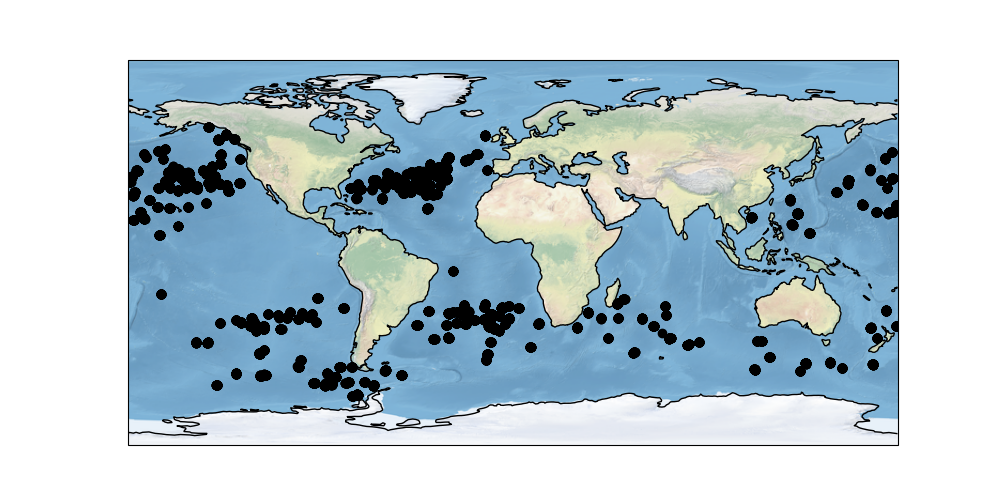

In [3]:
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# 2. Add background features
ax.coastlines()
ax.stock_img()  # Adds a basic background image of the earth

# Scatter the buoy points and color by time 
ax.scatter(
    sofar_data['lon'][:],
    sofar_data['lat'][:],
    color='k',
    transform=ccrs.PlateCarree(),
)

In [4]:
# Find unique sofar buoys
unique_count = len(np.unique(sofar_data['lstn']))
print(f"Number of unique buoys: {unique_count}")

# Unique buoys 
unique_buoy_ids = np.unique(sofar_data['lstn'])
print(unique_buoy_ids)

Number of unique buoys: 260
['SPOT-010034' 'SPOT-010064' 'SPOT-010065' 'SPOT-010069' 'SPOT-010089'
 'SPOT-010094' 'SPOT-010110' 'SPOT-010128' 'SPOT-010148' 'SPOT-010151'
 'SPOT-010154' 'SPOT-010167' 'SPOT-010192' 'SPOT-010194' 'SPOT-010196'
 'SPOT-010221' 'SPOT-010235' 'SPOT-010251' 'SPOT-010266' 'SPOT-010268'
 'SPOT-010293' 'SPOT-010294' 'SPOT-010298' 'SPOT-010299' 'SPOT-010307'
 'SPOT-010317' 'SPOT-010322' 'SPOT-010329' 'SPOT-010336' 'SPOT-010342'
 'SPOT-010350' 'SPOT-010368' 'SPOT-010373' 'SPOT-010378' 'SPOT-010380'
 'SPOT-010382' 'SPOT-010394' 'SPOT-010404' 'SPOT-010410' 'SPOT-010411'
 'SPOT-010415' 'SPOT-010423' 'SPOT-010428' 'SPOT-010436' 'SPOT-010437'
 'SPOT-010451' 'SPOT-010460' 'SPOT-0361' 'SPOT-0406' 'SPOT-0409'
 'SPOT-0414' 'SPOT-0442' 'SPOT-0445' 'SPOT-0449' 'SPOT-0451' 'SPOT-0460'
 'SPOT-0462' 'SPOT-0463' 'SPOT-0466' 'SPOT-0546' 'SPOT-0563' 'SPOT-0565'
 'SPOT-0609' 'SPOT-0614' 'SPOT-0632' 'SPOT-0652' 'SPOT-0654' 'SPOT-0669'
 'SPOT-0677' 'SPOT-0679' 'SPOT-0687' 'SPOT-0692' 

In [5]:
# Plot the output from the forecast grib file 
gfs_fname = '../data/gfs.20260101/00/wave/gridded/gfswave.t00z.global.0p25.f000.grib2'
gfs_ds = xr.open_dataset(gfs_fname, engine="cfgrib", backend_kwargs={'indexpath':''})
gfs_ds

<xarray.Dataset> Size: 79MB
Dimensions:              (latitude: 721, longitude: 1440, orderedSequenceData: 3)
Coordinates:
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    time                 datetime64[ns] 8B ...
    step                 timedelta64[ns] 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    ws                   (latitude, longitude) float32 4MB ...
    wdir                 (latitude, longitude) float32 4MB ...
    u                    (latitude, longitude) float32 4MB ...
    v                    (latitude, longitude) float32 4MB ...
    swh                  (latitude, longitude) float32 4MB ...
    perpw                (latitude, longitude) float32 4MB ...
    ...                   ...
    shww                 (latitude, longitude) float32 4MB ...
    shts                 (orderedSequenceData, latitude, longitude) float32 12MB ...
    mpww                 (latitude, longitude) float32 4MB ...
    mpts                 (orderedSequenceData, latitude, longitude) float32 12MB ...
    wvdir                (latitude, longitude) float32 4MB ...
    swdir                (orderedSequenceData, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-08T20:00 GRIB to CDM+CF via cfgrib-0.9.1...

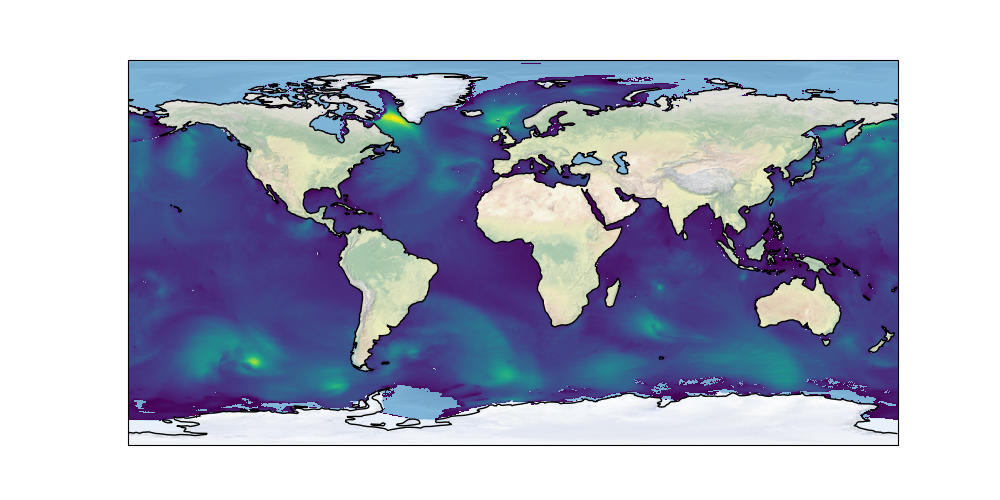

In [6]:
# Plot the GFS output for SWH
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# 2. Add background features
ax.coastlines()
ax.stock_img()  # Adds a basic background image of the earth

# Scatter the buoy points and color by time 
ax.pcolormesh(
    gfs_ds['longitude'][:],
    gfs_ds['latitude'][:],
    gfs_ds['swh'][:],
    transform=ccrs.PlateCarree(),
)

In [7]:
# Get Sofar data at the same time as the forecast data
print(f'Forecast start time {gfs_ds['time'].values}')
print(f'Time since start of forecast {gfs_ds['step'].values}')

print(gfs_ds['time'].values+np.timedelta64(3, 'h'))

# Find all sofar data values that occur at the same time as this forecast output
# need to make not manual and use the combined dataset
hour_num = 3
sofar_forecast_subset_ds = sofar_data.where((sofar_data.time >= gfs_ds['time'].values) & 
    (sofar_data.time <= gfs_ds['time'].values+np.timedelta64(hour_num, 'h')), drop=True)

sofar_forecast_subset_ds

Forecast start time 2026-01-01T00:00:00.000000000
Time since start of forecast 0 nanoseconds
2026-01-01T03:00:00.000000000


<xarray.Dataset> Size: 32kB
Dimensions:    (time: 472)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2026-01-01T01:01:00 ... 2026-01-01T0...
Data variables:
    lat        (time) float32 2kB -41.47 -24.37 -58.32 ... 35.83 -40.22 18.21
    lon        (time) float32 2kB 116.3 -12.77 -83.27 ... -35.39 73.1 133.2
    lstn       (time) object 4kB 'SPOT-010382' 'SPOT-010415' ... 'SPOT-31661C'
    buoy_type  (time) float64 4kB 9.0 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0 9.0
    hs         (time) float32 2kB 4.05 1.41 5.79 1.77 ... 1.62 4.0 2.77 1.57
    dsdw       (time) float64 4kB 12.0 26.0 17.0 29.0 ... 25.0 29.0 40.0 33.0
    ddwc       (time) float64 4kB 229.0 328.0 247.0 297.0 ... 301.0 83.0 75.0
    avwp       (time) float32 2kB 12.1 8.0 9.5 8.6 7.8 ... 7.2 6.0 7.9 7.0 7.2
    spwp       (time) float32 2kB 14.6 14.6 12.8 11.4 8.5 ... 9.3 11.4 8.5 7.9
    wspd       (time) float32 2kB 3.2 1.6 10.0 4.0 4.0 ... 8.0 6.0 7.6 8.4 4.4
    wdir       (time) float32 2kB 262.0 308.0 251.0 211.0 ... 337.0 91.0 74.0
Attributes:
    description:  Example sofar buoy data bufr
    source:       Converted from NCO BUFR data tanks

Text(0.5, 1.0, 'GFS output 2026-01-01T00:00:00.000000000 and Sofar buoy measurements')

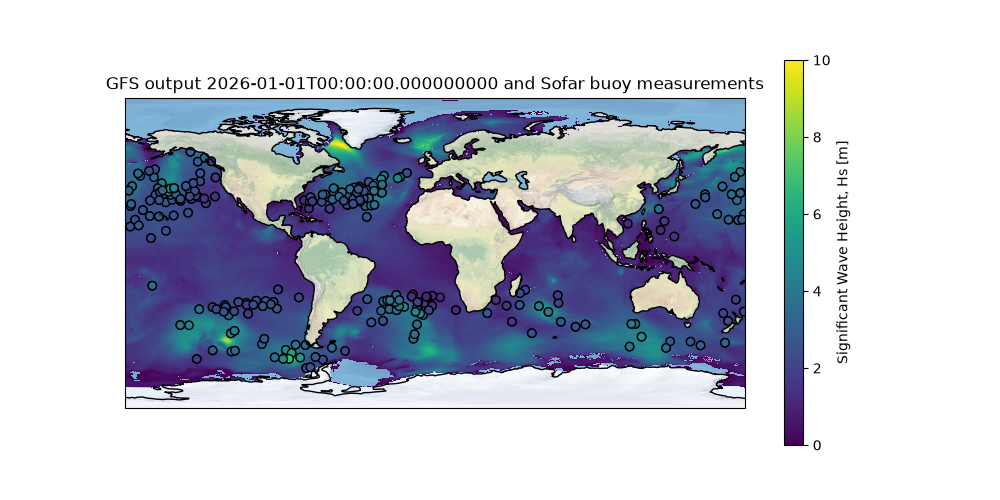

In [8]:
# Plot the GFS output for SWH
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# 2. Add background features
ax.coastlines()
ax.stock_img()  # Adds a basic background image of the earth

# Plot the forecast output
im1 = ax.pcolormesh(
                gfs_ds['longitude'][:],
                gfs_ds['latitude'][:],
                gfs_ds['swh'][:],
                transform=ccrs.PlateCarree(),
                vmin=0,
                vmax=10
            )

# Scatter the sofar subset during forecast time
im2 = ax.scatter(
                sofar_forecast_subset_ds['lon'][:],
                sofar_forecast_subset_ds['lat'][:],
                c=sofar_forecast_subset_ds['hs'][:],
                transform=ccrs.PlateCarree(),
                vmin=0,
                vmax=10,
                edgecolors='black'
            )

cbar2 = plt.colorbar(im2)
cbar2.set_label('Significant Wave Height, Hs [m]')

ax.set_title(f'GFS output {gfs_ds['time'].values} and Sofar buoy measurements')

In [9]:
# Load the next forcast hour - f003
gfs_f003_fname = '../data/gfs.20260101/00/wave/gridded/gfswave.t00z.global.0p25.f003.grib2'
gfs_f003_ds = xr.open_dataset(gfs_f003_fname, engine="cfgrib", backend_kwargs={'indexpath':''})
gfs_f003_ds

<xarray.Dataset> Size: 79MB
Dimensions:              (latitude: 721, longitude: 1440, orderedSequenceData: 3)
Coordinates:
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    time                 datetime64[ns] 8B ...
    step                 timedelta64[ns] 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    ws                   (latitude, longitude) float32 4MB ...
    wdir                 (latitude, longitude) float32 4MB ...
    u                    (latitude, longitude) float32 4MB ...
    v                    (latitude, longitude) float32 4MB ...
    swh                  (latitude, longitude) float32 4MB ...
    perpw                (latitude, longitude) float32 4MB ...
    ...                   ...
    shww                 (latitude, longitude) float32 4MB ...
    shts                 (orderedSequenceData, latitude, longitude) float32 12MB ...
    mpww                 (latitude, longitude) float32 4MB ...
    mpts                 (orderedSequenceData, latitude, longitude) float32 12MB ...
    wvdir                (latitude, longitude) float32 4MB ...
    swdir                (orderedSequenceData, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-08T20:02 GRIB to CDM+CF via cfgrib-0.9.1...

In [10]:
print(gfs_ds['step'].values)
print(gfs_f003_ds['step'].values)

0 nanoseconds
10800000000000 nanoseconds


In [11]:
# Concatenate the forecast hours
xr.set_options(use_new_combine_kwarg_defaults=True)
gfs_combined_ds = xr.concat([gfs_ds, gfs_f003_ds], dim="step")

# Shift time variable to be time reference - start of forecast
gfs_combined_ds = gfs_combined_ds.rename(time="time_ref")

# Compute a new time varaible as the ref time plus the time step 
gfs_combined_ds['time'] = gfs_combined_ds['time_ref'] + gfs_combined_ds['step']
gfs_combined_ds = gfs_combined_ds.swap_dims({"step": "time"})

gfs_combined_ds

<xarray.Dataset> Size: 158MB
Dimensions:              (time: 2, latitude: 721, longitude: 1440,
                          orderedSequenceData: 3)
Coordinates:
  * time                 (time) datetime64[ns] 16B 2026-01-01 2026-01-01T03:0...
    step                 (time) timedelta64[ns] 16B 00:00:00 03:00:00
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    time_ref             datetime64[ns] 8B 2026-01-01
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    ws                   (time, latitude, longitude) float32 8MB nan nan ... nan
    wdir                 (time, latitude, longitude) float32 8MB nan nan ... nan
    u                    (time, latitude, longitude) float32 8MB nan nan ... nan
    v                    (time, latitude, longitude) float32 8MB nan nan ... nan
    swh                  (time, latitude, longitude) float32 8MB nan nan ... nan
    perpw                (time, latitude, longitude) float32 8MB nan nan ... nan
    ...                   ...
    shww                 (time, latitude, longitude) float32 8MB nan nan ... nan
    shts                 (time, orderedSequenceData, latitude, longitude) float32 25MB ...
    mpww                 (time, latitude, longitude) float32 8MB nan nan ... nan
    mpts                 (time, orderedSequenceData, latitude, longitude) float32 25MB ...
    wvdir                (time, latitude, longitude) float32 8MB nan nan ... nan
    swdir                (time, orderedSequenceData, latitude, longitude) float32 25MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-08T20:00 GRIB to CDM+CF via cfgrib-0.9.1...

In [12]:
# Create a new sofar subset from the concatenated gfs output
n = 0
sofar_forecast_subset_ds = sofar_data.where((sofar_data.time >= gfs_combined_ds['time'].values[n]) & 
    (sofar_data.time <= gfs_combined_ds['time'].values[n+1]), drop=True)

sofar_forecast_subset_ds

<xarray.Dataset> Size: 32kB
Dimensions:    (time: 472)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2026-01-01T01:01:00 ... 2026-01-01T0...
Data variables:
    lat        (time) float32 2kB -41.47 -24.37 -58.32 ... 35.83 -40.22 18.21
    lon        (time) float32 2kB 116.3 -12.77 -83.27 ... -35.39 73.1 133.2
    lstn       (time) object 4kB 'SPOT-010382' 'SPOT-010415' ... 'SPOT-31661C'
    buoy_type  (time) float64 4kB 9.0 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0 9.0
    hs         (time) float32 2kB 4.05 1.41 5.79 1.77 ... 1.62 4.0 2.77 1.57
    dsdw       (time) float64 4kB 12.0 26.0 17.0 29.0 ... 25.0 29.0 40.0 33.0
    ddwc       (time) float64 4kB 229.0 328.0 247.0 297.0 ... 301.0 83.0 75.0
    avwp       (time) float32 2kB 12.1 8.0 9.5 8.6 7.8 ... 7.2 6.0 7.9 7.0 7.2
    spwp       (time) float32 2kB 14.6 14.6 12.8 11.4 8.5 ... 9.3 11.4 8.5 7.9
    wspd       (time) float32 2kB 3.2 1.6 10.0 4.0 4.0 ... 8.0 6.0 7.6 8.4 4.4
    wdir       (time) float32 2kB 262.0 308.0 251.0 211.0 ... 337.0 91.0 74.0
Attributes:
    description:  Example sofar buoy data bufr
    source:       Converted from NCO BUFR data tanks

In [13]:
# Interpolate the GFS output onto the sofar measurement time and lat/lon coordinates 
gfs2sofar_interp = gfs_combined_ds.interp(
                     time=sofar_forecast_subset_ds['time'], 
                     latitude=sofar_forecast_subset_ds['lat'], 
                     longitude=sofar_forecast_subset_ds['lon'], 
                     method="linear"
                    )

gfs2sofar_interp

<xarray.Dataset> Size: 83kB
Dimensions:              (time: 472, orderedSequenceData: 3)
Coordinates:
  * time                 (time) datetime64[ns] 4kB 2026-01-01T01:01:00 ... 20...
    step                 (time) timedelta64[ns] 4kB 01:01:00 ... 02:50:00
    latitude             (time) float32 2kB -41.47 -24.37 ... -40.22 18.21
    longitude            (time) float32 2kB 116.3 -12.77 -83.27 ... 73.1 133.2
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    time_ref             datetime64[ns] 8B 2026-01-01
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    ws                   (time) float64 4kB 2.752 nan nan ... nan 6.249 1.556
    wdir                 (time) float64 4kB 267.6 nan nan ... nan 324.3 214.9
    u                    (time) float64 4kB 2.719 nan nan ... nan 3.423 0.8663
    v                    (time) float64 4kB 0.02595 nan nan ... nan -5.132 1.266
    swh                  (time) float64 4kB 3.427 nan nan ... nan 2.683 1.252
    perpw                (time) float64 4kB 15.26 nan nan nan ... nan 7.83 7.641
    ...                   ...
    shww                 (time) float64 4kB nan nan nan nan ... nan nan nan nan
    shts                 (time, orderedSequenceData) float64 11kB 3.427 ... 0...
    mpww                 (time) float64 4kB nan nan nan nan ... nan nan nan nan
    mpts                 (time, orderedSequenceData) float64 11kB 15.26 ... 1...
    wvdir                (time) float64 4kB nan nan nan nan ... nan nan nan nan
    swdir                (time, orderedSequenceData) float64 11kB 230.0 ... 4...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-08T20:00 GRIB to CDM+CF via cfgrib-0.9.1...

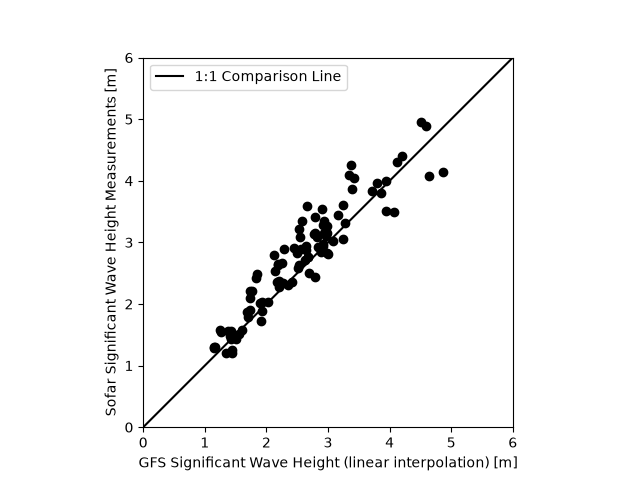

In [14]:
# Compare the Significant wave height from the GFS forecast to the sofar data 
fig, ax = plt.subplots()
ax.scatter(gfs2sofar_interp['swh'][:], sofar_forecast_subset_ds['hs'][:], c='k', marker='o')

# Plot characteristics
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xlabel('GFS Significant Wave Height (linear interpolation) [m]')
ax.set_ylabel('Sofar Significant Wave Height Measurements [m]')
ax.plot([0,6], [0,6], color='k', label='1:1 Comparison Line')
ax.legend()
ax.set_aspect('equal')

In [15]:
# Compute the RMSE between the GFS output and the sofar data
def rmse(obs, model):
    residual = model - obs
    mse = np.nanmean(residual**2)
    rmse_vals = np.sqrt(mse)
    return rmse_vals

# Compute the RMSE
hs_rmse = rmse(sofar_forecast_subset_ds['hs'].values, gfs2sofar_interp['swh'].values)
print(f'The RMSE for the first 3 hours of the global forecast is {np.round(hs_rmse, 3)} meters.')

The RMSE for the first 3 hours of the global forecast is 0.359 meters.


Text(0, 0.5, 'Significant Wave Height Residual, (Hs_gfs - Hs_sofar) [m]')

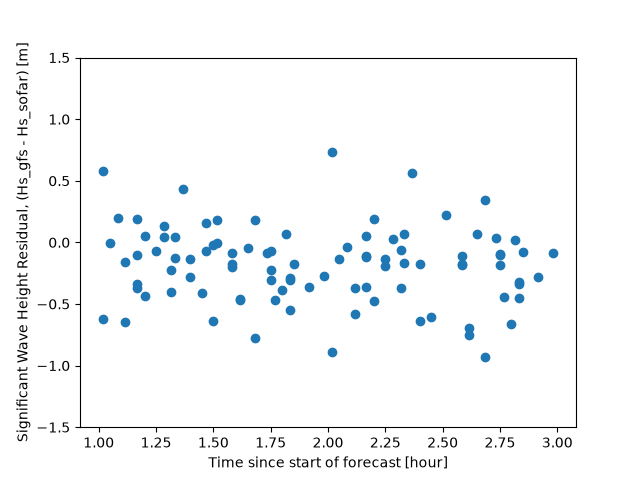

In [16]:
# Plot Residuals as a function of step
# print(gfs2sofar_interp['step'].values / np.timedelta64(1, 'm'))

fig, ax = plt.subplots()
ax.scatter(gfs2sofar_interp['step'].values / np.timedelta64(1, 'h'), 
        gfs2sofar_interp['swh'].values - sofar_forecast_subset_ds['hs'].values)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Time since start of forecast [hour]')
ax.set_ylabel('Significant Wave Height Residual, (Hs_gfs - Hs_sofar) [m]')

In [17]:
sofar_single_buoy_ds = sofar_data.isel(time=(sofar_data['lstn'] == 'SPOT-010382'))
sofar_single_buoy_ds

<xarray.Dataset> Size: 3kB
Dimensions:    (time: 46)
Coordinates:
  * time       (time) datetime64[ns] 368B 2026-01-01T01:01:00 ... 2026-01-02T...
Data variables:
    lat        (time) float32 184B -41.47 -41.47 -41.46 ... -41.58 -41.59 -41.6
    lon        (time) float32 184B 116.3 116.3 116.3 116.3 ... 116.4 116.4 116.5
    lstn       (time) object 368B 'SPOT-010382' 'SPOT-010382' ... 'SPOT-010382'
    buoy_type  (time) float64 368B 9.0 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0 9.0
    hs         (time) float32 184B 4.05 4.26 3.93 3.97 ... 2.47 2.38 2.31 2.36
    dsdw       (time) float64 368B 12.0 12.0 13.0 15.0 ... 22.0 22.0 23.0 21.0
    ddwc       (time) float64 368B 229.0 228.0 228.0 230.0 ... 232.0 231.0 231.0
    avwp       (time) float32 184B 12.1 12.4 12.2 12.2 12.3 ... 8.7 8.4 8.2 8.0
    spwp       (time) float32 184B 14.6 17.1 17.1 14.6 ... 11.4 11.4 11.4 11.4
    wspd       (time) float32 184B 3.2 2.8 2.8 3.2 3.2 ... 5.6 5.6 6.0 6.4 6.8
    wdir       (time) float32 184B 262.0 268.0 297.0 285.0 ... 337.0 331.0 331.0
Attributes:
    description:  Example sofar buoy data bufr
    source:       Converted from NCO BUFR data tanks

In [18]:
sofar_single_buoy_ds = sofar_data.isel(time=(sofar_data['lstn'] == 'SPOT-010064'))
sofar_single_buoy_ds

<xarray.Dataset> Size: 3kB
Dimensions:    (time: 45)
Coordinates:
  * time       (time) datetime64[ns] 360B 2026-01-01T01:39:00 ... 2026-01-02T...
Data variables:
    lat        (time) float32 180B -54.62 -54.62 -54.63 ... -54.75 -54.75 -54.75
    lon        (time) float32 180B 113.0 113.0 113.0 113.0 ... 113.3 113.3 113.3
    lstn       (time) object 360B 'SPOT-010064' 'SPOT-010064' ... 'SPOT-010064'
    buoy_type  (time) float64 360B 9.0 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0 9.0
    hs         (time) float32 180B 3.99 3.8 3.81 3.72 ... 2.48 2.27 2.27 2.1
    dsdw       (time) float64 360B 21.0 25.0 23.0 24.0 ... 27.0 31.0 27.0 31.0
    ddwc       (time) float64 360B 263.0 262.0 266.0 260.0 ... 253.0 254.0 259.0
    avwp       (time) float32 180B 8.3 8.1 8.2 8.1 8.2 ... 7.9 8.0 7.9 8.0 7.8
    spwp       (time) float32 180B 12.8 12.8 11.4 11.4 ... 11.4 11.4 11.4 11.4
    wspd       (time) float32 180B 10.8 10.4 10.0 10.0 9.2 ... 6.0 5.2 4.0 4.0
    wdir       (time) float32 180B 291.0 291.0 297.0 314.0 ... 274.0 285.0 302.0
Attributes:
    description:  Example sofar buoy data bufr
    source:       Converted from NCO BUFR data tanks

In [19]:
sofar_single_buoy_ds = sofar_data.isel(time=(sofar_data['lstn'] == 'SPOT-010065'))
sofar_single_buoy_ds

<xarray.Dataset> Size: 3kB
Dimensions:    (time: 46)
Coordinates:
  * time       (time) datetime64[ns] 368B 2026-01-01T01:48:00 ... 2026-01-02T...
Data variables:
    lat        (time) float32 184B -30.44 -30.44 -30.45 ... -30.69 -30.7 -30.71
    lon        (time) float32 184B 49.14 49.15 49.15 49.16 ... 49.16 49.16 49.15
    lstn       (time) object 368B 'SPOT-010065' 'SPOT-010065' ... 'SPOT-010065'
    buoy_type  (time) float64 368B 9.0 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0 9.0
    hs         (time) float32 184B 2.53 2.79 2.68 2.95 ... 2.63 2.49 2.58 2.52
    dsdw       (time) float64 368B 24.0 19.0 19.0 15.0 ... 26.0 32.0 21.0 35.0
    ddwc       (time) float64 368B 117.0 115.0 116.0 113.0 ... 116.0 121.0 121.0
    avwp       (time) float32 184B 7.8 8.2 8.2 8.5 8.4 ... 6.9 7.2 6.9 7.1 6.8
    spwp       (time) float32 184B 10.2 10.2 10.2 11.4 ... 11.4 11.4 10.2 11.4
    wspd       (time) float32 184B 5.2 4.4 4.4 4.4 4.8 ... 6.4 6.4 7.2 6.8 9.2
    wdir       (time) float32 184B 137.0 148.0 154.0 154.0 ... 68.0 68.0 68.0
Attributes:
    description:  Example sofar buoy data bufr
    source:       Converted from NCO BUFR data tanks

Each buoy reports at the same time but each hour and we get hourly measurements from each buoy but they each come in at at different minute of the hour. For example, 'SPOT-010065' comes in at minute 48, 'SPOT-010064' comes in at minute 39, and 'SPOT-010382' at minute 0. 

In [20]:
# # Concatenate the whole forecast into one dataset
# # Concatenate the forecast hours
# xr.set_options(use_new_combine_kwarg_defaults=True)

# # Get a list of the forecast grib files
# directory_path = '/scratch3/NCEPDEV/marine/Edwin.Rainville/sofar/data/gfs.20260101/00/wave/gridded/'
# files = glob.glob(f'{directory_path}*.grib2')
# print(len(files))
# print(files[n])

# # Make a base dataset to add to
# n = 0
# gfs_combined_ds = xr.open_dataset(files[n], engine="cfgrib", backend_kwargs={'indexpath':''})

# # Open the next dataset and concatenate it to the original
# for n in range(len(files)-1):
#     gfs_ds_next_file = xr.open_dataset(files[n+1], engine="cfgrib", backend_kwargs={'indexpath':''})
#     gfs_combined_ds = xr.concat([gfs_combined_ds, gfs_ds_next_file], dim="step")

# # NOTE: this takes about 13 minutes to run - I will plan to save the combined data so I dont need to rerun this each time for analysis
# # Save the combined datset
# gfs_combined_ds.to_netcdf("gfs_forecast_combined.nc")

# gfs_combined_ds


In [21]:
# Load the combined gfs data back in 
gfs_combined_ds = xr.open_dataset('./gfs_forecast_combined.nc', engine='netcdf4')

gfs_combined_ds

<xarray.Dataset> Size: 10GB
Dimensions:              (time: 129, latitude: 721, longitude: 1440,
                          orderedSequenceData: 3)
Coordinates:
  * time                 (time) datetime64[ns] 1kB 2026-01-11T21:00:00 ... 20...
    step                 (time) timedelta64[ns] 1kB ...
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    time_ref             datetime64[ns] 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    ws                   (time, latitude, longitude) float32 536MB ...
    wdir                 (time, latitude, longitude) float32 536MB ...
    u                    (time, latitude, longitude) float32 536MB ...
    v                    (time, latitude, longitude) float32 536MB ...
    swh                  (time, latitude, longitude) float32 536MB ...
    perpw                (time, latitude, longitude) float32 536MB ...
    ...                   ...
    shww                 (time, latitude, longitude) float32 536MB ...
    shts                 (time, orderedSequenceData, latitude, longitude) float32 2GB ...
    mpww                 (time, latitude, longitude) float32 536MB ...
    mpts                 (time, orderedSequenceData, latitude, longitude) float32 2GB ...
    wvdir                (time, latitude, longitude) float32 536MB ...
    swdir                (time, orderedSequenceData, latitude, longitude) float32 2GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-03T20:53 GRIB to CDM+CF via cfgrib-0.9.1...

In [22]:
# # Shift time variable to be time reference - start of forecast
# gfs_combined_ds = gfs_combined_ds.rename(time="time_ref")

# # Compute a new time varaible as the ref time plus the time step 
# gfs_combined_ds['time'] = gfs_combined_ds['time_ref'] + gfs_combined_ds['step']
# gfs_combined_ds = gfs_combined_ds.swap_dims({"step": "time"})

# gfs_combined_ds

In [23]:
gfs2sofar_interp = gfs_combined_ds.interp(
                     time=sofar_data['time'], 
                     latitude=sofar_data['lat'], 
                     longitude=sofar_data['lon'], 
                     method="linear"
                    )

gfs2sofar_interp

<xarray.Dataset> Size: 2MB
Dimensions:              (time: 11062, orderedSequenceData: 3)
Coordinates:
  * time                 (time) datetime64[ns] 88kB 2026-01-01T01:01:00 ... 2...
    step                 (time) timedelta64[ns] 88kB 01:01:00 ... 1 days 23:5...
    latitude             (time) float32 44kB -41.47 -24.37 -58.32 ... 29.5 44.25
    longitude            (time) float32 44kB 116.3 -12.77 ... -70.61 174.2
  * orderedSequenceData  (orderedSequenceData) float64 24B 1.0 2.0 3.0
    time_ref             datetime64[ns] 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables: (12/13)
    ws                   (time) float64 88kB 2.752 nan nan nan ... nan nan 6.067
    wdir                 (time) float64 88kB 267.6 nan nan nan ... nan nan 343.5
    u                    (time) float64 88kB 2.719 nan nan ... nan nan 0.7195
    v                    (time) float64 88kB 0.02595 nan nan ... nan nan -6.014
    swh                  (time) float64 88kB 3.427 nan nan nan ... nan nan 4.558
    perpw                (time) float64 88kB 15.26 nan nan nan ... nan nan 11.63
    ...                   ...
    shww                 (time) float64 88kB nan nan nan nan ... nan nan nan nan
    shts                 (time, orderedSequenceData) float64 265kB 3.427 ... nan
    mpww                 (time) float64 88kB nan nan nan nan ... nan nan nan nan
    mpts                 (time, orderedSequenceData) float64 265kB 15.26 ... nan
    wvdir                (time) float64 88kB nan nan nan nan ... nan nan nan nan
    swdir                (time, orderedSequenceData) float64 265kB 230.0 ... nan
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-03T20:53 GRIB to CDM+CF via cfgrib-0.9.1...

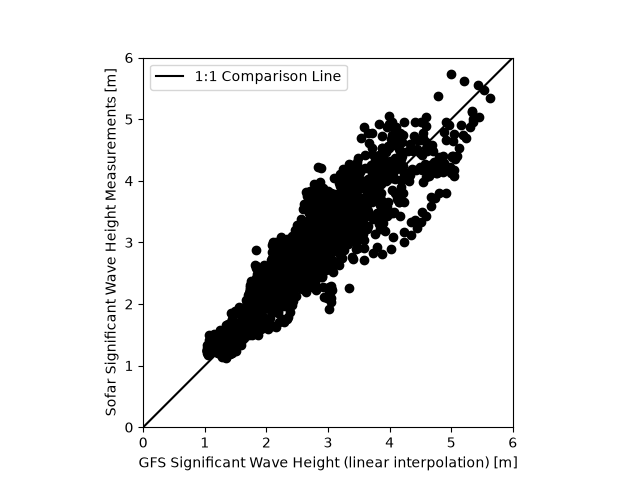

In [24]:
# Compare the Significant wave height from the GFS forecast to the sofar data 
fig, ax = plt.subplots()
ax.scatter(gfs2sofar_interp['swh'][:], sofar_data['hs'][:], c='k', marker='o')

# Plot characteristics
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xlabel('GFS Significant Wave Height (linear interpolation) [m]')
ax.set_ylabel('Sofar Significant Wave Height Measurements [m]')
ax.plot([0,6], [0,6], color='k', label='1:1 Comparison Line')
ax.legend()
ax.set_aspect('equal')

Text(0, 0.5, 'Significant Wave Height Residual, (Hs_gfs - Hs_sofar) [m]')

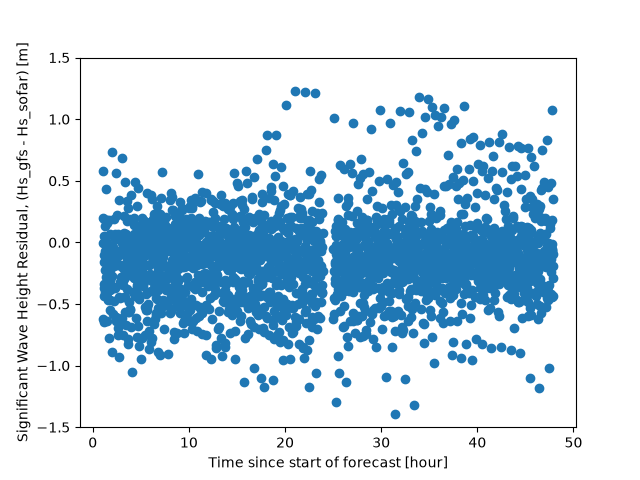

In [25]:
fig, ax = plt.subplots()
ax.scatter(gfs2sofar_interp['step'].values / np.timedelta64(1, 'h'), 
        gfs2sofar_interp['swh'].values - sofar_data['hs'].values)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Time since start of forecast [hour]')
ax.set_ylabel('Significant Wave Height Residual, (Hs_gfs - Hs_sofar) [m]')

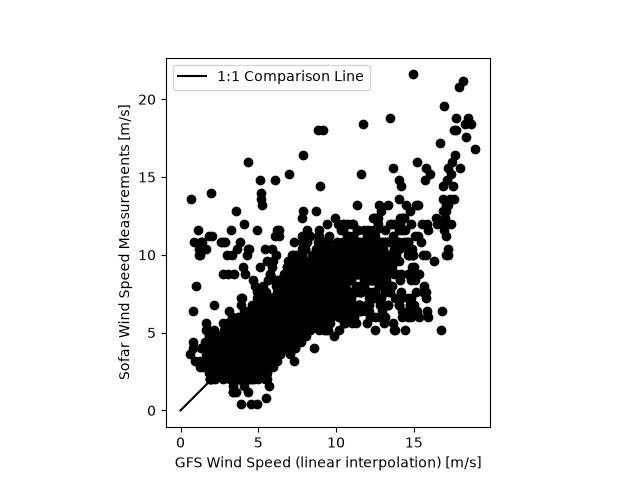

In [26]:
# Compare the Significant wave height from the GFS forecast to the sofar data 
fig, ax = plt.subplots()
ax.scatter(gfs2sofar_interp['ws'][:], sofar_data['wspd'][:], c='k', marker='o')

# Plot characteristics
# ax.set_xlim(0, 6)
# ax.set_ylim(0, 6)
ax.set_xlabel('GFS Wind Speed (linear interpolation) [m/s]')
ax.set_ylabel('Sofar Wind Speed Measurements [m/s]')
ax.plot([0,6], [0,6], color='k', label='1:1 Comparison Line')
ax.legend()
ax.set_aspect('equal')

Text(0, 0.5, 'Wind Speed Residual, (wind_speed_gfs - wind_speed_sofar) [m/s]')

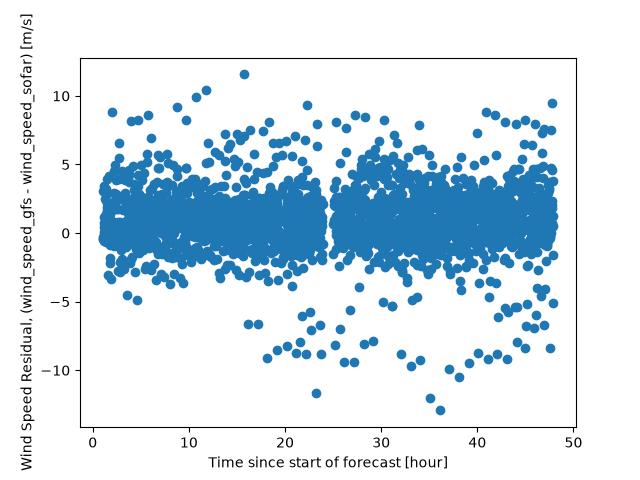

In [27]:
fig, ax = plt.subplots()
ax.scatter(gfs2sofar_interp['step'].values / np.timedelta64(1, 'h'), 
        gfs2sofar_interp['ws'].values - sofar_data['wspd'].values)
ax.set_xlabel('Time since start of forecast [hour]')
ax.set_ylabel('Wind Speed Residual, (wind_speed_gfs - wind_speed_sofar) [m/s]')

In [28]:
print(np.nanmax(gfs2sofar_interp['wdir'].values))
print(np.nanmax(sofar_data['wdir'].values))

355.8567354747035
354.0
